<div style="font-family: 'Segoe UI', Arial, sans-serif; 
            border-left: 5px solid #1f77b4; 
            padding: 20px; 
            background-color: #f8f9fa; 
            border-radius: 4px; 
            box-shadow: 0 1px 3px rgba(0,0,0,0.05); 
            max-width: 800px; 
            margin-bottom: 25px;">
    
<h1 style="color: #212529; margin-top: 0; margin-bottom: 5px; font-size: 26px; font-weight: 700;">
    Part I: Simplified CMS Open Data
</h1>
<br>
<p style="color: #6c757d; margin-top: 0; margin-bottom: 20px; font-size: 18px; font-weight: bold;">
    Notebook 4: $Z \rightarrow e^+e^-$ Reconstruction: Lepton Channel Comparison
</p>

<hr style="border: 0; border-top: 1px solid #dee2e6; margin-bottom: 15px;">

<table style="border-collapse: collapse; width: 100%; font-size: 14px; line-height: 1.6;">
    <tr>
        <td style="padding: 4px 0; width: 150px; font-weight: bold; color: #495057;">Author:</td>
        <td style="padding: 4px 0; color: #212529;">Uditangshu Roy</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Affiliation:</td>
        <td style="padding: 4px 0; color: #212529;">Undergraduate, Department of Physics and Astronomy, The University of Manchester</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Contact:</td>
        <td style="padding: 4px 0; color: #1f77b4; text-decoration: none;">roy.uditangshu@gmail.com</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Date:</td>
        <td style="padding: 4px 0; color: #212529;">August 2026</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Dataset Source:</td>
        <td style="padding: 4px 0; color: #212529;">CERN Open Data: <i> Z to two electrons from 2011</i>. McCauley, T. Recorded 2011. Published 2019.</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Software Env.:</td>
        <td style="padding: 4px 0; color: #212529;">Python 3.11+, Pandas, Matplotlib, NumPy, Pathlib, IPython</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">ORCID:</td>
        <td style="padding: 4px 0; color: #212529; font-family: monospace; letter-spacing: 0.5px;"><a href="https://orcid.org/0009-0005-7992-3549">0009-0005-7992-3549</a></td>
    </tr>
</table>
</div>

## 1. &nbsp; Introduction

The invariant mass reconstruction performed in the previous notebook demonstrated that the $Z$-boson can be successfully identified through its decay into a pair of muons. However, the Standard Model predicts that the $Z$-boson couples similarly to all charged leptons, allowing the same reconstruction procedure to be applied to electron pairs. This notebook therefore extends the analysis to the $Z \rightarrow e^+e^-$ decay channel using the simplified CMS Open Data sample. The objective is to verify that the reconstruction framework developed for muons is equally applicable to electrons (generation 1 leptons) and to compare the reconstructed mass spectra obtained from the two lepton species.

In [1]:
#Import libraries and modules

import sys
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utilities import (
    dataset_information,
    TABLE_STYLES
)

from src.fourvectors import (
    invariant_mass_exact,
    invariant_mass_massless
)

from src.plotting import (
    set_plot_style,
    histogram_peak,
    plot_histogram,
    plot_overlay_histogram
)

from src.particles import *

set_plot_style()  #sets matplotlib rc-params

#Center-align outputs
display(HTML("""
<style>
.jp-OutputArea-output {
    display: flex;
    justify-content: center;
    align-items: center;
}
</style>
"""))

In [2]:
#Load Dataset
zee = pd.read_csv("../../data/raw/simplified/zee_10k.csv")

## 2. &nbsp; Di-electron Dataset Analysis

As done previously with the double-muon dataset, the data analysed in this notebook are also obtained from the CMS Open Data programme. Unlike muons, which are reconstructed using the silicon tracking system together with the dedicated muon chambers, electrons are identified primarily through their interaction with the electromagnetic calorimeter (ECAL). As electrons traverse the detector they produce electromagnetic showers, allowing their energy to be measured with high precision. The simplified dataset therefore includes several electron-specific observables, including the shower shape variable $\sigma_{\eta\eta}$, the hadronic-to-electromagnetic energy ratio $H/E$, and separate isolation quantities measured in the tracker, ECAL and HCAL. Although these quantities are useful for electron identification in experimental analyses, only the reconstructed momentum variables are required for invariant mass reconstruction.

### 2.1 &nbsp; Dataset Inspection

In [3]:
(dataset_information(zee)
    .style.set_caption("<b>Table 1:</b> Data Types")
    .set_table_styles(TABLE_STYLES)
)

,Data Type,Non-Null Entries
Run,int64,10000
Event,int64,10000
pt1,float64,10000
eta1,float64,10000
phi1,float64,10000
Q1,int64,10000
type1,str,10000
sigmaEtaEta1,float64,10000
HoverE1,float64,10000
isoTrack1,float64,10000


The dataset information confirms that all variables have been imported successfully with appropriate numerical data types. The majority of the columns are stored as floating-point values, reflecting the continuous nature of the measured kinematic quantities, while the run number, event number, and particle charges are represented as integers. The absence of unexpected data types indicates that the dataset has been read correctly and is suitable for numerical analysis.

### 2.2 &nbsp; Dataset Semantics

The dataset is of the following structure:

<div style="font-family: 'Segoe UI', Arial, sans-serif; 
            margin: 15px auto 25px auto; 
            max-width: 800px;
            border-left: 5px solid #165683; 
            padding: 8px; 
            background-color: #f8f9fa; 
            border-radius: 4px; 
            box-shadow: 0 1px 3px rgba(0,0,0,0.05);
            text-align:center;">
    <h3 style="color: #333; margin-bottom: 12px; font-size:15px; text-align:left">Table 2: Dataset Variable Dictionary</h3>
    <table style="border-collapse: collapse; width: 100%; box-shadow: 0 2px 5px rgba(0,0,0,0.05); border-radius: 4px; overflow: hidden; text-align:left;">
        <thead>
            <tr style="background-color: #343a40; color: white; text-align: left;">
                <th style="padding: 12px; font-size: 14px; width: 120px;">Variable</th>
                <th style="padding: 12px; font-size: 14px; width: 100px;">Unit / Type</th>
                <th style="padding: 12px; font-size: 14px;">Description</th>
            </tr>
        </thead>
        <tbody>
            <tr style="background-color: #f8f9fa; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">Run</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">Integer</td>
                <td style="padding: 10px 12px; color: #495057;">The run number of the event.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">Event</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">Integer</td>
                <td style="padding: 10px 12px; color: #495057;">The event number.</td>
            </tr>
            <tr style="background-color: #f8f9fa; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">pt</td>
                <td style="padding: 10px 12px; color: #e83e8c; font-weight: 500; font-size: 13px;">GeV</td>
                <td style="padding: 10px 12px; color: #495057;">The transverse momentum ($p_T$) of the electron.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">eta</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">Float</td>
                <td style="padding: 10px 12px; color: #495057;">The pseudorapidity ($\eta$) of the electron.</td>
            </tr>
            <tr style="background-color: #f8f9fa; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">phi</td>
                <td style="padding: 10px 12px; color: #e83e8c; font-weight: 500; font-size: 13px;">rad</td>
                <td style="padding: 10px 12px; color: #495057;">The azimuthal angle ($\phi$) of the electron.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">Q</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">&plusmn;1</td>
                <td style="padding: 10px 12px; color: #495057;">The charge of the electron.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">type</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">string (EB/EE)</td>
                <td style="padding: 10px 12px; color: #495057;">Either EB or EE: whether the electron is in the barrel or in the endcap.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">sigmaEtaEta</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">float</td>
                <td style="padding: 10px 12px; color: #495057;">The weighted cluster rms along eta for an electron.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">HoverE</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">float</td>
                <td style="padding: 10px 12px; color: #495057;">The energy of the electron in the HCAL divided by the energy of the electron in the ECAL.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">isoTrack</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">Scalar (Float)</td>
                <td style="padding: 10px 12px; color: #495057;">The isolation variable for the electron in the tracker.</td>
            </tr>
            <tr style="background-color: #ffffff; border-bottom: 1px solid #dee2e6;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">isoEcal</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">Scalar (Float)</td>
                <td style="padding: 10px 12px; color: #495057;">The isolation variable for the electron in the ECAL.</td>
            </tr>
            <tr style="background-color: #ffffff;">
                <td style="padding: 10px 12px; font-family: monospace; font-weight: bold; color: #1f77b4;">isoHcal</td>
                <td style="padding: 10px 12px; color: #6c757d; font-size: 13px;">Scalar (Float)</td>
                <td style="padding: 10px 12px; color: #495057;">The isolation variable for the electron in the HCAL.</td>
            </tr>
        </tbody>
    </table>
</div>

### 2.3 &nbsp; Data Selection Procedure

For the double electron $Z \rightarrow e^+e^-$ dataset, an event was selected if there were two electrons in the event with $p_T > 25 \: \text{GeV}$ and the invariant mass of the two electrons was in the range of 60 GeV to 120 GeV.

## 3. &nbsp; Electron Reconstruction

### 3.1 &nbsp; ECAL Detector Regions (EB/EE)

Unlike muons, electrons are reconstructed primarily using the electromagnetic calorimeter (ECAL), where they deposit their energy through the production of electromagnetic showers. The CMS ECAL is divided into two principal regions: the barrel (EB), covering the central region of the detector, and the endcaps (EE), which extend the detector acceptance to larger pseudorapidities. The dataset records the detector region in which each electron was reconstructed, allowing the detector acceptance of the selected events to be examined.

In [4]:
summary_df = pd.DataFrame({
    "Type 1": zee["type1"].value_counts(),
    "Type 2": zee["type2"].value_counts()
}).fillna(0).astype(int) 


full_forms = {
    "EB": "ECAL Barrel",
    "EE": "ECAL Endcap"
}

summary_df = summary_df.rename(index=full_forms)

(summary_df
    .style.set_caption("<b>Table 3:</b> Distribution of ECAL Detector Regions")
    .set_table_styles(TABLE_STYLES)
)

,Type 1,Type 2
ECAL Barrel,7589,6120
ECAL Endcap,2411,3880


The majority of reconstructed electrons are observed within the ECAL barrel, while a smaller proportion are reconstructed in the endcaps. This behaviour is consistent with the detector geometry and acceptance, as the barrel covers the central pseudorapidity region where a large fraction of collision products are detected. The presence of electrons in both detector regions demonstrates that the selected events span a broad range of production angles.

### 3.2 &nbsp; Electromagnetic Shower Shape ($\sigma_{\eta\eta}$)

As electrons traverse the ECAL they generate electromagnetic showers through repeated decay radiation and pair production. The variable $\sigma_{\eta\eta}$ characterises the lateral width of these showers in pseudorapidity and is commonly used within CMS to distinguish genuine electrons from hadronic backgrounds. Prompt electrons are expected to produce relatively compact electromagnetic showers, resulting in small values of this observable.

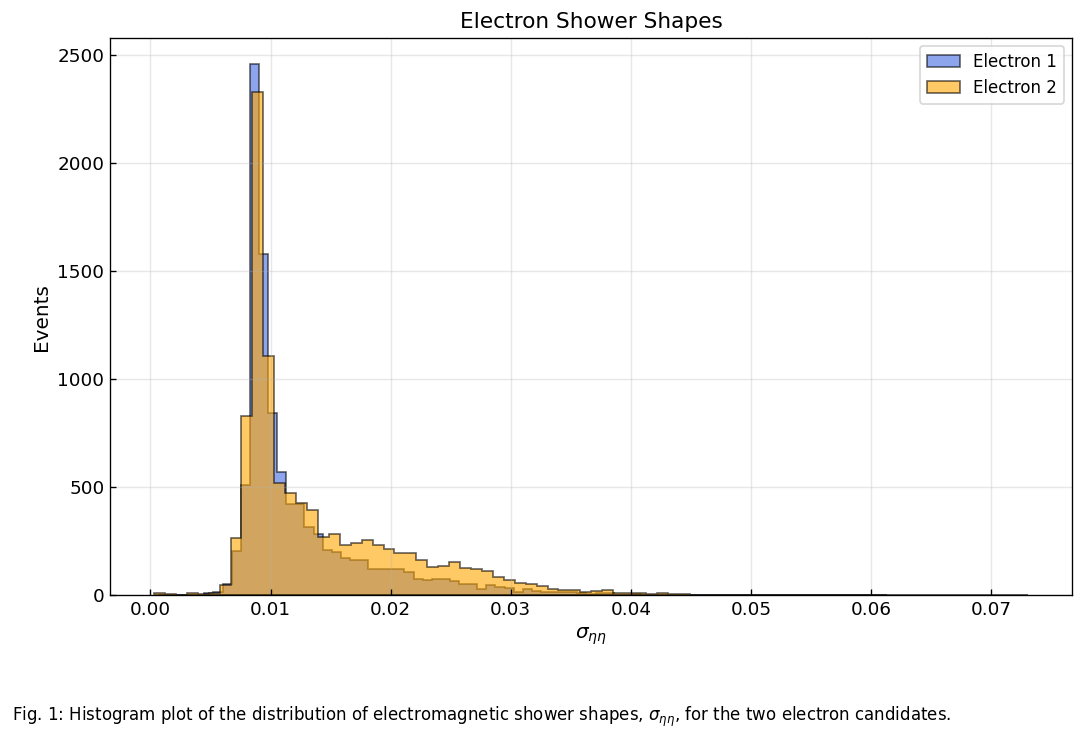

In [5]:
plot_overlay_histogram(
    zee["sigmaEtaEta1"],
    zee["sigmaEtaEta2"],
    bins=80,
    xlabel=r"$\sigma_{\eta\eta}$",
    ylabel="Events",
    title="Electron Shower Shapes",
    label1="Electron 1",
    label2="Electron 2",
    caption=r"Fig. 1: Histogram plot of the distribution of electromagnetic shower shapes, $\sigma_{\eta\eta}$, for the two electron candidates."
)

Both reconstructed electrons exhibit distributions that sharply increase from low values of $\sigma_{\eta\eta}$ to a clear peak at small $\sigma_{\eta\eta}$ near 0.01, indicating that the majority of events contain compact electromagnetic showers. Beyond this peak, the distribution shows a decreasing tail extending toward larger values, gradually falling to near zero by approximately $\sigma_{\eta\eta} \sim 0.04$. This behaviour is consistent with well-reconstructed prompt electrons and demonstrates that the simplified dataset is dominated by high-quality electron candidates suitable for invariant mass reconstruction.

### 3.3 &nbsp; Hadronic Leakage

The quantity $H/E$ is defined as the ratio of the energy deposited in the hadronic calorimeter (HCAL) to that deposited in the electromagnetic calorimeter (ECAL). Electrons interact predominantly through the electromagnetic force and therefore deposit nearly all of their energy within the ECAL, resulting in H/E values close to zero. Consequently, this variable provides an effective discriminator between electrons and hadronic particles.

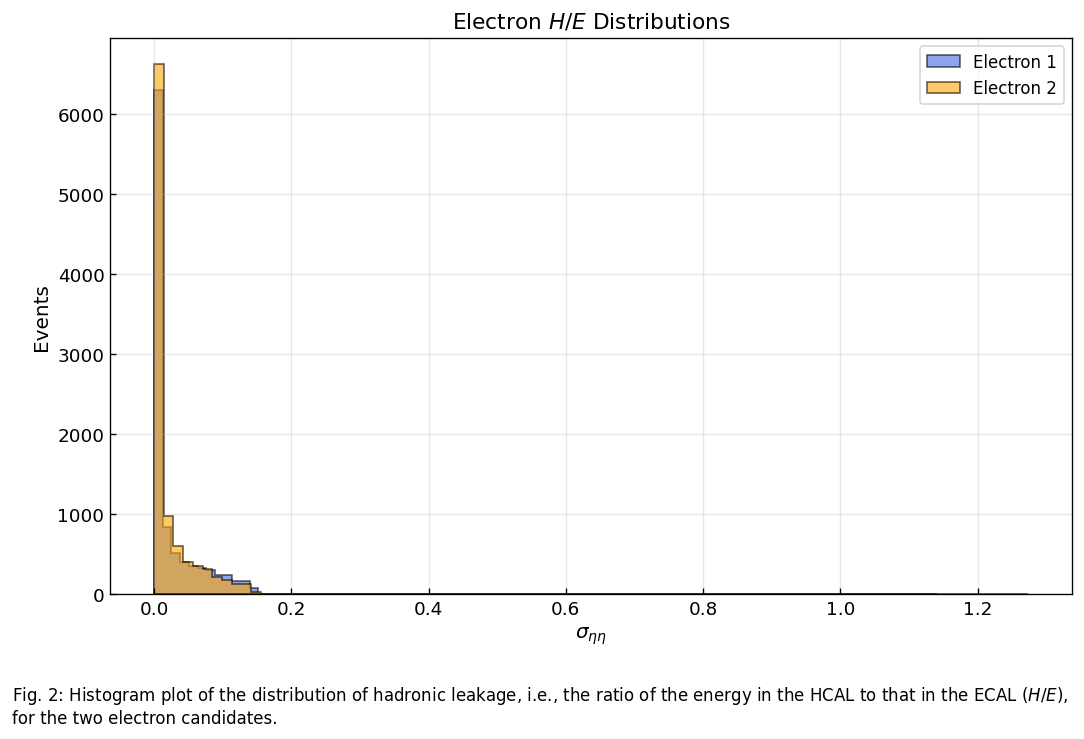

In [6]:
plot_overlay_histogram(
    zee["HoverE1"],
    zee["HoverE2"],
    bins=90,
    xlabel=r"$\sigma_{\eta\eta}$",
    ylabel="Events",
    title=r"Electron $H/E$ Distributions",
    label1="Electron 1",
    label2="Electron 2",
    caption=r"Fig. 2: Histogram plot of the distribution of hadronic leakage, i.e., the ratio of the energy in the HCAL to that in the ECAL ($H/E$), for the two electron candidates."
)

The $H/E$ distributions exhibit a pronounced peak near zero, followed by a trailing distribution extending to the right, indicating that the selected particles deposit only a very small fraction of their energy within the hadronic calorimeter. This behaviour is characteristic of genuine electrons and provides additional confidence in the quality of the reconstructed event sample.

### 3.4 &nbsp; Electron Isolation

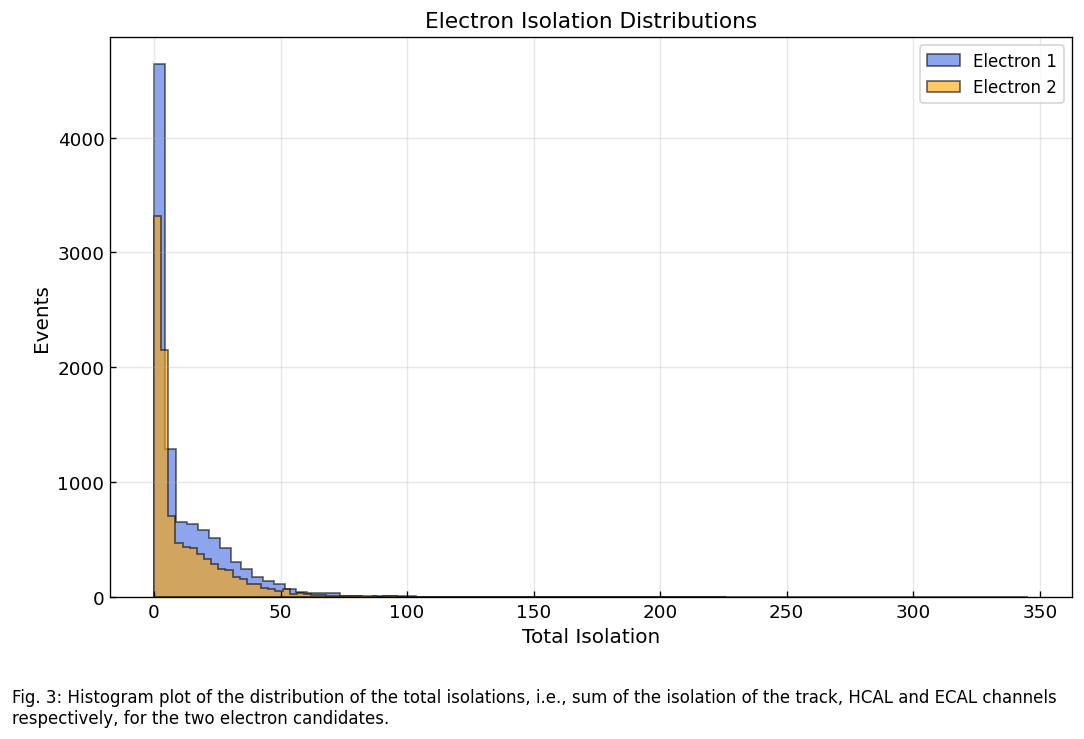

In [7]:
iso_total_1 = (
    zee["isoTrack1"]
    + zee["isoEcal1"]
    + zee["isoHcal1"]
)

iso_total_2 = (
    zee["isoTrack2"]
    + zee["isoEcal2"]
    + zee["isoHcal2"]
)

plot_overlay_histogram(
    iso_total_1,
    iso_total_2,
    bins=80,
    xlabel="Total Isolation",
    ylabel="Events",
    title=r"Electron Isolation Distributions",
    label1="Electron 1",
    label2="Electron 2",
    caption=r"Fig. 3: Histogram plot of the distribution of the total isolations, i.e., sum of the isolation of the track, HCAL and ECAL channels respectively, for the two electron candidates."
)

The combined isolation distributions display strong peaks near zero with gradually decreasing tails towards larger values. This indicates that the majority of reconstructed electrons are well isolated from neighbouring detector activity, consistent with prompt electrons originating from the decay of a $Z$-boson. Only a relatively small number of events exhibit larger isolation values, suggesting increased nearby particle activity within those events.

## 4. &nbsp; Invariant Mass Reconstruction

Having established that the selected electrons exhibit the expected detector characteristics, the invariant mass of each electron pair can now be reconstructed using the same relativistic formalism introduced in the dimuon analysis. The only modification required is the substitution of the electron rest mass for that of the muon. Since the electron rest mass is approximately two hundred times smaller than the muon rest mass and many orders of magnitude smaller than the typical particle energies observed in the selected events, the exact relativistic calculation and the massless approximation are expected to produce almost identical results. The rest mass energy of the muon is taken as $0.51099895069 \: \text{MeV}$, with a standard uncertainty of $1.6 \times 10^{-10} \: \text{MeV}$ [1]. This is exceptionally small, with a relative standard uncertainty of just $3.1 \times 10^{-10}$, even lower than that of the muon mass.

### 4.1 &nbsp; Exact Invariant Mass

Similar to the dimuon analysis, the exact invariant mass calculation retains the finite rest mass of the electron throughout the reconstruction, therefore serving as a benchmark against which the massless approximation can be compared in the subsequent sections.

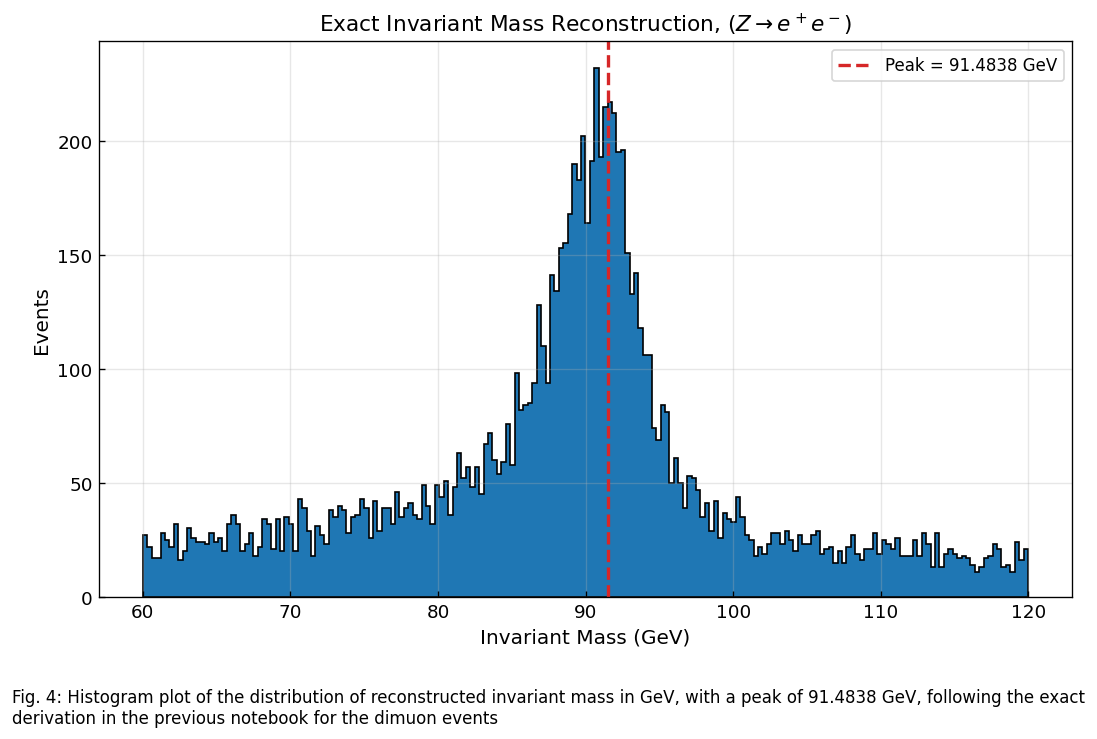

In [8]:
M_inv_exact = invariant_mass_exact(zee, rest_mass=ELECTRON_REST_MASS)

peak_exact = histogram_peak(M_inv_exact)

plot_histogram(
    M_inv_exact,
    bins=200,
    xlabel="Invariant Mass (GeV)",
    title=r"Exact Invariant Mass Reconstruction, ($Z \rightarrow e^+e^-$)",
    color="#1f77b4",
    vlines=[(peak_exact, f"Peak = {peak_exact:.4f} GeV", "#d62728")],
    caption=f"Fig. 4: Histogram plot of the distribution of reconstructed invariant mass in GeV, with a peak of {peak_exact:.4f} GeV, following the exact derivation in the previous notebook for the dimuon events",
    save_path="../../figures/z_ee_exact_mass_reconstruction_part_1.png",
    alt_caption=f"""Histogram plot of the distribution of reconstructed invariant mass of the $Z \\rightarrow e^- e^+$ sample in GeV, illustrated in blue, \
following a similar process to that of the exact invariant mass derivation in notebook 3, section 2.1, without any approximations. \
The dashed red line depicts the peak of the histogram at {peak_exact:.4f} GeV.
"""
)

### 4.2 &nbsp; Massless Approximation

As mentioned in previous notebooks, at LHC energies, the momentum of each reconstructed muon is typically several hundred times larger than its rest mass. Therefore, the electron having even less mass than the muon, it may be approximated as a massless particle, allowing the invariant mass expression to be simplified considerably. This approximation is widely employed in experimental particle physics because it reduces the computational complexity while introducing only a negligible error in the reconstructed mass.

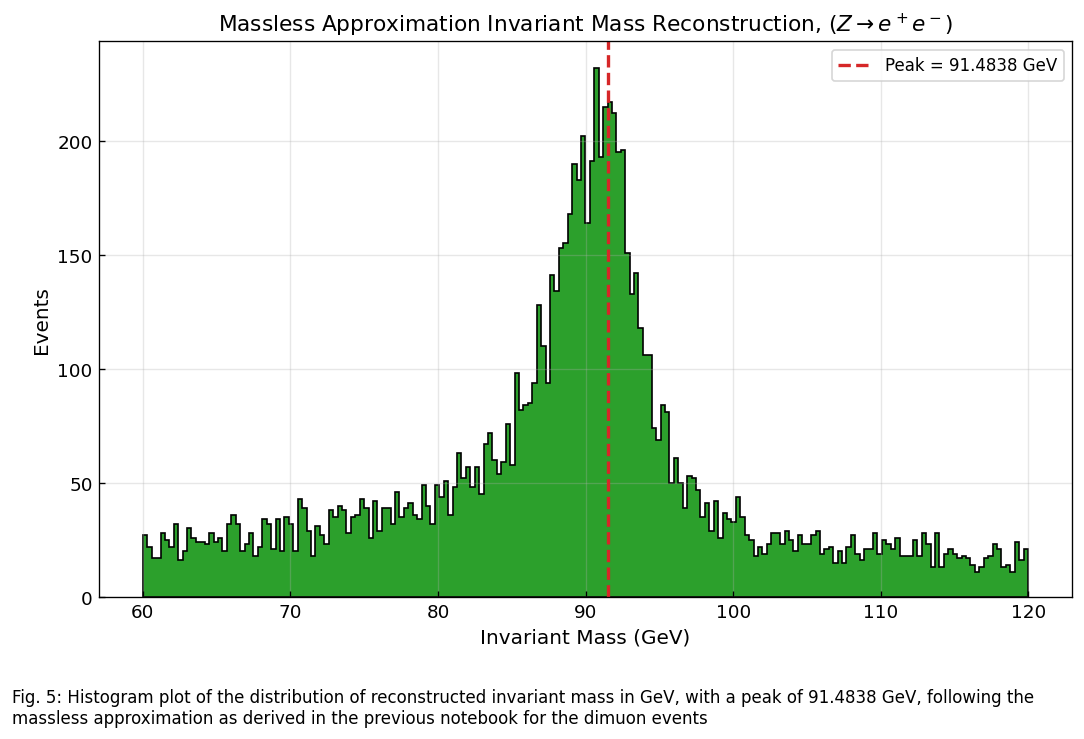

In [9]:
M_inv_massless = invariant_mass_massless(zee)

peak_massless = histogram_peak(M_inv_massless)

plot_histogram(
    M_inv_massless,
    bins=200,
    xlabel="Invariant Mass (GeV)",
    title=r"Massless Approximation Invariant Mass Reconstruction, ($Z \rightarrow e^+e^-$)",
    color="#2ca02c",
    vlines=[(peak_massless, f"Peak = {peak_massless:.4f} GeV", "#d62728")],
    caption=f"Fig. 5: Histogram plot of the distribution of reconstructed invariant mass in GeV, with a peak of {peak_exact:.4f} GeV, following the massless approximation as derived in the previous notebook for the dimuon events",
    save_path="../../figures/z_mumu_massless_approx_reconstruction_part_1.png",
    alt_caption=f"""Histogram plot of the distribution of reconstructed invariant mass of the $Z \\rightarrow \\mu^- \\mu^+$ sample in GeV, illustrated in green, \
following a similar process to the massless approximation derived in notebook 3, section 2.2, which assumes a negligible electron rest mass. \
The dashed red line depicts the peak of the histogram at {peak_massless:.4f} GeV.
"""
)

## 5. &nbsp; Comparison of Reconstruction Methods for Dimuon Events

### 5.1 &nbsp; Statistical Comparison

In [10]:
#Display comparison, similar to dimuon events

diff_array = np.abs(M_inv_exact - M_inv_massless)  #Difference in two methods

mean_diff= np.mean(diff_array)
max_diff  = np.max(diff_array)
min_diff  = np.min(diff_array)
peak_diff = np.abs(peak_exact - peak_massless)

stat_data = {
    "Quantity": [
        "Mean Absolute Difference", 
        "Maximum Difference", 
        "Minimum Difference", 
        "Exact Peak Position", 
        "Massless Approx. Peak Position", 
        "Peak Difference"
    ],
    "Value (GeV)": [
        mean_diff, 
        max_diff, 
        min_diff, 
        peak_exact, 
        peak_massless, 
        peak_diff
    ]
}

df = pd.DataFrame(stat_data)

stats_comparison_table = (
    df.style
    .format(
        {"Value (GeV)": "{:.3e}"},
        subset=pd.IndexSlice[[0, 1, 2, 5], ["Value (GeV)"]]
    )
    # To format the peak positions (indices 3, 4) as standard floats
    .format(
        {"Value (GeV)": "{:.4f}"},
        subset=pd.IndexSlice[[3, 4], ["Value (GeV)"]]
    )
    .hide(axis="index")
    .set_table_styles(TABLE_STYLES)
    .set_caption("<b>Table 4:</b> Statistical comparison between exact and massless approximation methods.")
)

stats_comparison_table

Quantity,Value (GeV)
Mean Absolute Difference,7.105e-09
Maximum Difference,2.844e-08
Minimum Difference,4.356e-09
Exact Peak Position,91.4838
Massless Approx. Peak Position,91.4838
Peak Difference,9.410e-09


### 5.2 &nbsp; Event-by-Event Difference

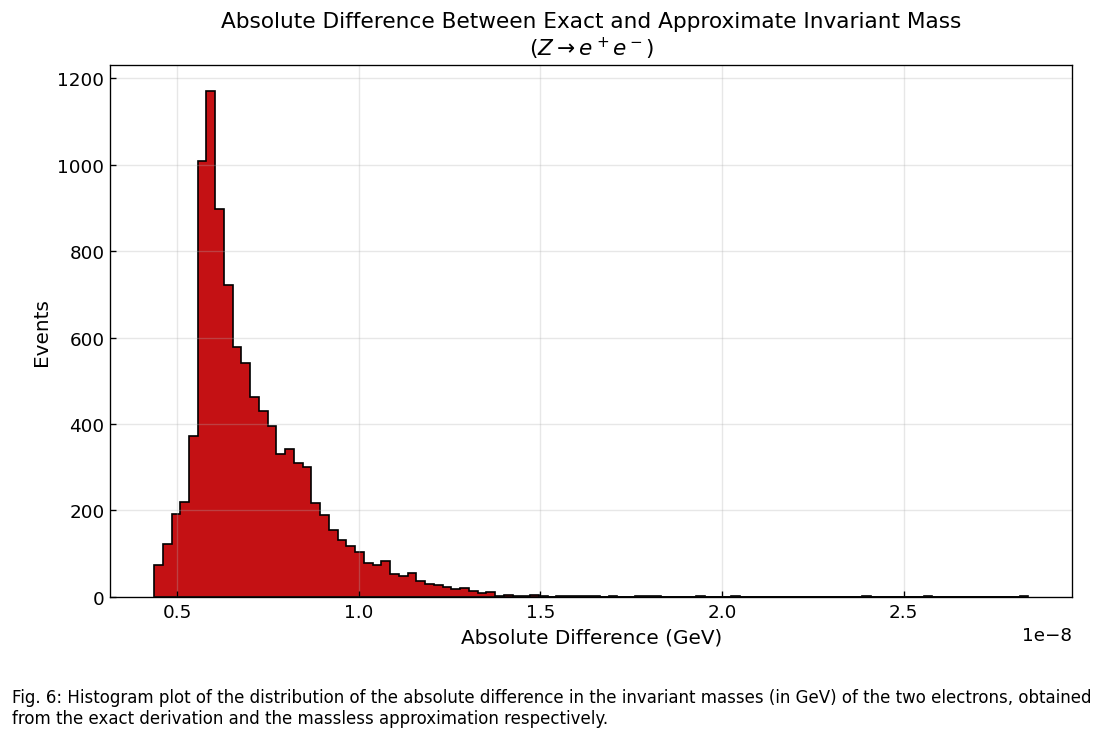

In [11]:
plot_histogram(
    diff_array,
    bins=100,
    xlabel="Absolute Difference (GeV)",
    color="#c41114",
    title=("Absolute Difference Between Exact and Approximate Invariant Mass\n" +
          r"($Z \rightarrow e^+e^-$)"
    ),
    caption=f"Fig. 6: Histogram plot of the distribution of the absolute difference in the invariant masses (in GeV) of the two electrons, obtained from the exact derivation and the massless approximation respectively."
)

The event-by-event comparison demonstrates that the invariant masses reconstructed using the exact relativistic expression and the massless approximation are in essentially perfect agreement across the entire dielectron dataset. The distribution of absolute differences is now overwhelmingly concentrated at values extremely close to zero, with no appreciable broad structure between the two methods. This reflects the extremely small rest mass of the electron and demonstrates that treating the electron as massless introduces only a minute correction at the energies considered in the dataset.

The mean absolute difference between the reconstructed invariant masses is approximately $7.11 \times 10^{-9}\,\text{GeV}$, corresponding to $7.11 \times 10^{-6}\,\text{MeV}$. The largest observed difference within the dataset is only $2.84 \times 10^{-8}\,\text{GeV}$, or approximately $2.84 \times 10^{-5}\,\text{MeV}$, while the smallest difference is $4.36 \times 10^{-9}\,\text{GeV}$. These differences are many orders of magnitude smaller than the characteristic energy scale of the reconstructed $Z$-boson resonance and are therefore completely negligible for the purposes of this analysis.

The invariant mass spectra reconstructed using the exact relativistic calculation and the massless approximation are effectively indistinguishable. Both methods produce a resonance peak at approximately $91.4838\,\text{GeV}$, with a peak difference of only $9.41 \times 10^{-9}\,\text{GeV}$. This corresponds to a relative difference of approximately $1.03 \times 10^{-10}$, demonstrating that the finite, small electron rest mass has no measurable effect on the reconstructed $Z$-boson mass at the precision of this dataset.

Overall, the comparison demonstrates that the massless approximation is an exceptionally accurate description of the electron kinematics in high-energy $Z \rightarrow e^+e^-$ events. In contrast to the dimuon analysis, where the finite muon rest mass produced small but measurable event-by-event differences, the much smaller electron rest mass causes the exact and massless calculations to agree to approximately the $10^{-9}\,\text{GeV}$ level. Consequently, for the energy scale considered here, the electron can effectively be treated as massless without introducing any physically significant change to the reconstructed $Z$-boson invariant mass.

### 5.3 &nbsp; Comparison with the Accepted Peak Value

The invariant mass spectrum reconstructed from the simplified CMS Open Data exhibits a clear resonance centred at approximately $91.48\,\text{GeV}$, corresponding to the production of the (Z)-boson. This reconstructed value differs from the accepted Particle Data Group value of $91.1879\,\text{GeV}$ [2] by approximately $0.30\,\text{GeV}$, representing a relative deviation of approximately $0.32\%$.

This small discrepancy is expected and does not indicate an error in the reconstruction procedure. The dataset used in this project is a simplified educational sample rather than the complete CMS experimental dataset, and therefore does not incorporate the full detector calibration, detector alignment, energy calibration or sophisticated reconstruction algorithms employed in precision CMS analyses. Furthermore, the peak position has been estimated from a binned histogram, meaning that its exact value depends slightly on the chosen bin width and the finite size of the event sample. Despite these limitations, the reconstructed resonance is in excellent agreement with the accepted $Z$-boson mass and demonstrates that the invariant mass reconstruction has been successfully extended to the dielectron decay channel.

### 5.4 &nbsp; Saving Results
This section performs the necessary computations to save and store the results obtained from the di-electron events data in a csv file format, in the path <code>../../data/processed/dielectron_part_1_summary.csv</code>. The large array of the entire distribution of the invariant mass is stored using NumPy's binary format, as <code>../../data/interim/dielectron_part_1_exact_mass.npy</code>.

In [12]:
results = pd.DataFrame({
    "Quantity": [
        "Exact Peak",
        "Approximate Peak",
        "Peak Difference",
        "Mean Approximation Error",
        "Maximum Approximation Error",
        "Minimum Approximation Error",
        "Difference from PDG Value"
    ],
    "Value (GeV)": [
        peak_exact,
        peak_massless,
        peak_diff,
        mean_diff,
        max_diff,
        min_diff,
        np.abs(peak_exact - PDG_Z_MASS)
    ]
})

results.to_csv("../../data/processed/dielectron_part_1_summary.csv", index=False)


#Save the exact invariant mass distribution
np.save("../../data/interim/dielectron_part_1_exact_mass.npy", M_inv_exact)

## 6. &nbsp; Comparison with the Muon Channel

The Standard Model predicts that the $Z$-boson couples universally to the charged leptons, allowing it to decay into both muon and electron pairs with nearly identical branching fractions. Consequently, the invariant mass reconstruction developed for the dimuon channel should also reproduce the characteristic $Z$-boson resonance in the di-electron channel. Comparing the two decay modes provides an important consistency check of the reconstruction framework while illustrating how different detector technologies measure the same underlying physical process.

### 6.1 &nbsp; Comparison of Reconstruction Results

In [13]:
#Read results of the dimuon events stored in csv file format
muon_results = pd.read_csv("../../data/processed/dimuon_part_1_summary.csv")
muon_data = dict(zip(
    muon_results["Quantity"],
    muon_results["Value (GeV)"]
))

electron_results = pd.read_csv("../../data/processed/dielectron_part_1_summary.csv")
electron_data = dict(zip(
    electron_results["Quantity"],
    electron_results["Value (GeV)"]
))

comparison_data = {
    "Quantity": [
        "Exact Peak (GeV)", 
        "Approximate Peak (GeV)", 
        "Peak Difference (MeV)", 
        "Mean Approximation Error (MeV)", 
        "Maximum Approximation Error (MeV)",
        "Minimum Approximation Error (MeV)",
        "Difference from PDG Value (GeV)"
    ],
    r"$Z \rightarrow \mu^+\mu^-$": [
        muon_data["Exact Peak"], muon_data["Approximate Peak"], muon_data["Peak Difference"] * 1000, 
        muon_data["Mean Approximation Error"] * 1000, muon_data["Maximum Approximation Error"] * 1000, 
        muon_data["Minimum Approximation Error"] * 1000, muon_data["Difference from PDG Value"]
    ],
    r"$Z \rightarrow e^+e^-$": [
        electron_data["Exact Peak"], electron_data["Approximate Peak"], electron_data["Peak Difference"] * 1000, 
        electron_data["Mean Approximation Error"] * 1000, electron_data["Maximum Approximation Error"] * 1000, 
        electron_data["Minimum Approximation Error"] * 1000, electron_data["Difference from PDG Value"]
    ]
}

df = pd.DataFrame(comparison_data)

ee_col = r"$Z \rightarrow e^+e^-$"
mumu_col = r"$Z \rightarrow \mu^+\mu^-$"

stats_comparison_table = (
    df.style
    # Standard float format for the entire Muon column
    .format({mumu_col: "{:.4f}"})
    
    # Standard float format for Electron column: first two rows (0, 1) and last row (6)
    .format(
        {ee_col: "{:.4f}"},
        subset=pd.IndexSlice[[0, 1, 6], [ee_col]]
    )
    
    # Exponential format for Electron column: middle rows (2, 3, 4, 5)
    .format(
        {ee_col: "{:.2e}"},
        subset=pd.IndexSlice[[2, 3, 4, 5], [ee_col]]
    )
    
    .hide(axis="index")
    .set_table_styles(TABLE_STYLES)
    .set_caption("<b>Table 5:</b> Comparison of mass reconstruction statistics between the dimuon and di-electron channels.")
)

display(stats_comparison_table)
print(f"\nAbsolute difference in exact invariant mass peaks of the two channels: {np.abs(muon_data['Exact Peak'] - electron_data['Exact Peak']):.3f} GeV")

Quantity,$Z \rightarrow \mu^+\mu^-$,$Z \rightarrow e^+e^-$
Exact Peak (GeV),90.8770,91.4838
Approximate Peak (GeV),90.8767,91.4838
Peak Difference (MeV),0.2994,9.41e-06
Mean Approximation Error (MeV),0.3075,7.10e-06
Maximum Approximation Error (MeV),7.2060,2.84e-05
Minimum Approximation Error (MeV),0.1881,4.36e-06
Difference from PDG Value (GeV),0.3109,0.2959



Absolute difference in exact invariant mass peaks of the two channels: 0.607 GeV


Table 5 summarises the principal reconstruction results obtained for both decay channels. Although the reconstructed peak positions differ slightly, both channels successfully reproduce the characteristic $Z$-boson resonance close to the accepted Particle Data Group value [2]. The agreement demonstrates that the invariant mass reconstruction procedure is robust and may be applied consistently to different lepton species despite their differing detector signatures. Both channels show a similar level of agreement with the PDG reference value, with differences from the accepted $Z$-boson mass of approximately $0.311 \,\text{GeV}$ for the dimuons and $0.296 \,\text{GeV}$ for the di-electrons. Overall, while the electron channel exhibits relatively larger reconstruction uncertainties, both channels remain consistent with the expected $Z$-boson mass within experimental resolution.

### 6.2 &nbsp; Comparison of Invariant Mass Spectra

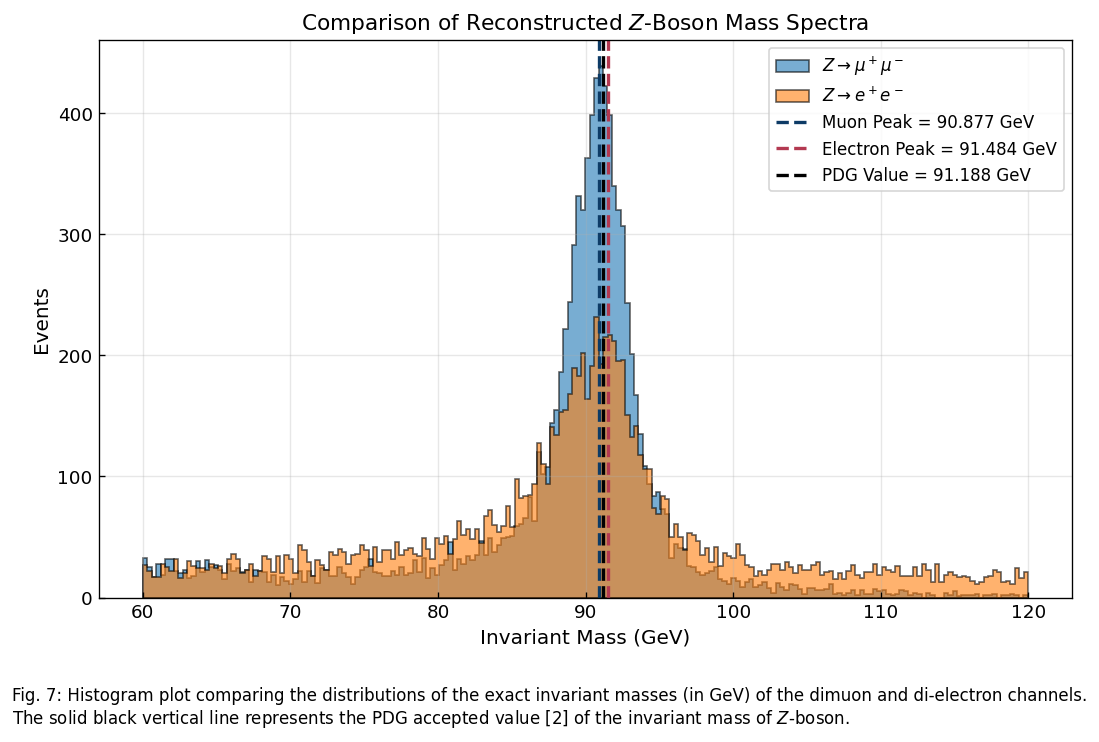

In [14]:
M_inv_exact_muon = np.load("../../data/interim/dimuon_part_1_exact_mass.npy")
M_inv_exact_electron = np.load("../../data/interim/dielectron_part_1_exact_mass.npy")

plot_overlay_histogram(
    M_inv_exact_muon,
    M_inv_exact_electron,
    bins=200,
    xlabel="Invariant Mass (GeV)",
    ylabel="Events",
    title=r"Comparison of Reconstructed $Z$-Boson Mass Spectra",
    colors=("#1f77b4", "#ff7f0e"),
    label1=r"$Z\rightarrow\mu^+\mu^-$",
    label2=r"$Z\rightarrow e^+e^-$",
    vlines=[
        (muon_data["Exact Peak"], f"Muon Peak = {muon_data['Exact Peak']:.3f} GeV", "#0d3b66"),
        (electron_data["Exact Peak"], f"Electron Peak = {electron_data['Exact Peak']:.3f} GeV", "#b33951"),
        (PDG_Z_MASS, f"PDG Value = {PDG_Z_MASS:.3f} GeV", "black")    
    ],
    caption=f"""Fig. 7: Histogram plot comparing the distributions of the exact invariant masses (in GeV) of the dimuon and di-electron channels.\
 The solid black vertical line represents the PDG accepted value [2] of the invariant mass of $Z$-boson.""",
    save_path="../../figures/z_mumu_ee_mass_spectra_comparison_part_1.png",
    alt_caption=f"""Histogram plot comparing the distributions of the exact invariant masses (in GeV) of the dimuon and di-electron channels.\
 The solid dashed dark blue and red lines represent the previously obtained exact mass peaks of the dimuon and di-electron channels respectively.\
 The solid dashed black vertical line represents the PDG accepted value, {PDG_Z_MASS:.3f} GeV, of the invariant mass of $Z$-boson."""
)

It is evident from Figure 7 that in both cases, a pronounced resonance is observed to be $\approx 91 \, \text{GeV}$, demonstrating the successful reconstruction of the $Z$-boson mass irrespective of the lepton species. The close agreement of both spectra with the accepted Particle Data Group value [2] confirms that the invariant mass reconstruction procedure developed throughout this project is both robust and physically consistent.

Although the resonance appears in both channels at nearly the same mass, several differences between the distributions are evident. The dimuon spectrum exhibits a relatively narrow and symmetric peak centred at approximately $90.88 \, \text{GeV}$, while the di-electron spectrum is broader and displays a more substantial population of events away from the resonance. Consequently, the electron channel produces a lower peak height despite containing the same number of reconstructed events. This broader distribution indicates that the reconstructed electron invariant masses are spread over a wider range of values than those obtained from the muon sample.

The reconstructed peak positions differ by approximately $0.607 \, \text{GeV}$, with the muon peak lying slightly below the accepted value and the electron peak lying slightly above it. Both deviations are nevertheless small, corresponding to less than one percent of the $Z$-boson mass. Such differences are expected within simplified educational datasets and arise primarily from the detector response and reconstruction procedures rather than from any underlying physical distinction between the two decay modes.

Overall, the comparison demonstrates one of the fundamental predictions of the Standard Model: the $Z$-boson may be reconstructed consistently through multiple leptonic decay channels using the same relativistic formalism. Despite the differing detector signatures and reconstruction techniques associated with muons and electrons, both analyses successfully recover the characteristic $Z$-boson peak characteristic, providing strong validation of the computational methods developed throughout this project.

## 7. &nbsp; Discussion and Conclusion

Although the same relativistic reconstruction procedure has been applied in both analyses, the two decay channels exhibit small quantitative differences. Muons are reconstructed primarily using the silicon tracking detectors together with the dedicated muon chambers, where their momentum is determined from the curvature of their trajectories within the CMS magnetic field. Electrons, by contrast, deposit most of their energy within the electromagnetic calorimeter (ECAL), making their reconstruction more sensitive to calorimeter energy measurements and electromagnetic shower development.

These differing detector technologies naturally lead to small variations in the reconstructed invariant mass spectra. Nevertheless, both decay channels reproduce the $Z$-boson resonance with excellent agreement relative to the accepted Particle Data Group value [2], demonstrating that the invariant mass reconstruction is largely independent of the final-state lepton species.

In conclusion, the comparison presented in this notebook demonstrates that the invariant mass reconstruction developed for the dimuon channel generalises successfully to electron pairs without modification to the underlying formalism. Having validated the reconstruction framework using two simplified datasets, the project now progresses to Part II, where the same methodology will be applied to larger and more realistic CMS Open Data samples requiring event selection, quality filtering and more advanced analysis techniques.

## References

[1] <https://physics.nist.gov/cgi-bin/cuu/Value?mec2mev>. _CODATA value: electron mass energy equivalent in MeV_¸ National Institute of Standards and Technology, U.S. Department of Commerce. 2022. Date accessed 27/07/2026.<br>
[2] <https://pdg.lbl.gov/2026/listings/rpp2026-list-z-boson.pdf>. Takahashi, F. _et al_. Particle Data Group. Int. J. Mod. Phys. A 41, 2630011 (2026)